# Predictive Alerting Systems: Supervised vs. Unsupervised Paradigms

## Project Goal and Dataset Evolution
The objective of this project is to design and implement a predictive alerting system capable of anticipating incidents based on historical metric data. Cloud service metrics present unique modeling challenges, including weak correlations, short-lived patterns, abrupt regime shifts, and heavy-tailed distributions. 

Initially, I explored the NASA Soil Moisture Active Passive (SMAP) telemetry dataset to proxy these complex systems. However, during the exploratory phase, I discovered a critical structural limitation: most of the telemetry channels contain only a single recorded anomaly sequence. This single-anomaly constraint completely breaks the supervised learning strategy. To train a predictive classifier, the dataset must be chronologically split so the model can learn precursor patterns during training while reserving a completely unseen incident for evaluation. A single incident cannot be split across both phases.

Therefore, I have focused this project on the Pooled Server Metrics (PSM) dataset released by eBay. This dataset aligns with cloud-infrastructure challenges and contains multiple, distinct server incidents within the same timeline, fully supporting a custom chronological split.

## Methodology and Data Strategy
To thoroughly investigate the optimal architecture, I am implementing two fundamentally different machine learning paradigms. Crucially, each approach requires a different strategy for utilizing the dataset files.

1. **The Supervised Binary Classifier:** The primary task is framed as a supervised, sliding-window binary classification problem: using the previous $W$ time steps of multivariate telemetry to predict the probability of an incident occurring within the subsequent $H$ time steps. For this approach, I am exclusively using the `test.csv` file. The provided `train.csv` is entirely anomaly-free; if I trained a classifier on it, the model would simply learn to predict a stable state forever. By performing a custom split directly on `test.csv`, I guarantee the classifier actually has incident data to learn from during its training phase.
2. **The Unsupervised Signal Reconstruction (The NASA Baseline):** As a comparative baseline, I am replicating NASA's original anomaly detection methodology. This approach does not predict a binary label; instead, it learns to reconstruct what a "normal" signal looks like and flags an anomaly when the actual data deviates too far from the prediction. For this approach, I will use the `train.csv` file to teach the model the baseline of healthy server operations, and then evaluate its detection capabilities on the `test.csv` file.

## Structure of the Data 
The PSM dataset consists of continuous, expert-labeled telemetry from internal application servers. The primary components are:
* **Ground Truth Labels**: The `test_label.csv` file contains a continuous binary sequence mapping the exact time steps of true server incidents (e.g., memory leaks, resource contention).
* **Telemetry Arrays**: The raw multivariate time-series data is stored in `test.csv` (and `train.csv` for the unsupervised baseline). The dataset tracks 26 concurrent dimensions representing various internal server metrics, anonymized to evaluate algorithmic generalization rather than domain-specific heuristics.

## Project Architecture and Modular Design
To ensure the code is maintainable and aligned with professional software standards, I have organized the project into a modular directory structure. The core engineering logic is encapsulated in the `/src` directory, allowing this notebook to serve as a high-level research journal focused on visualization and performance analysis.

The system is powered by two primary modules:
* **`preprocessing.py`**: Manages the ingestion of the raw telemetry, the three-way chronological split, and the multivariate sliding-window formulation.
* **`models.py`**: Contains the architectures for the supervised classifiers, allowing for a streamlined training pipeline.

## Phase One Strategy: Supervised Binary Classification
The supervised alerting task requires the model to identify patterns in a 30-step historical window that indicate a failure is likely within the next 10 steps. To investigate the trade-offs between different mathematical approaches, I am implementing a dual-classifier strategy:

1. **Long Short-Term Memory (LSTM):** This recurrent neural network is designed to respect the sequence of events, learning how the server's state evolves over the window.
2. **Histogram-based Gradient Boosting:** This acts as a robust, non-neural network baseline. It evaluates the metrics across the window as a flattened tabular structure, which is often more effective at handling the noisy, "heavy-tailed" distributions found in real-world server logs.

Both models undergo a probability calibration phase using a dedicated slice of the timeline. This ensures that the danger scores they produce are empirically accurate, helping to avoid alert fatigue in a production setting.

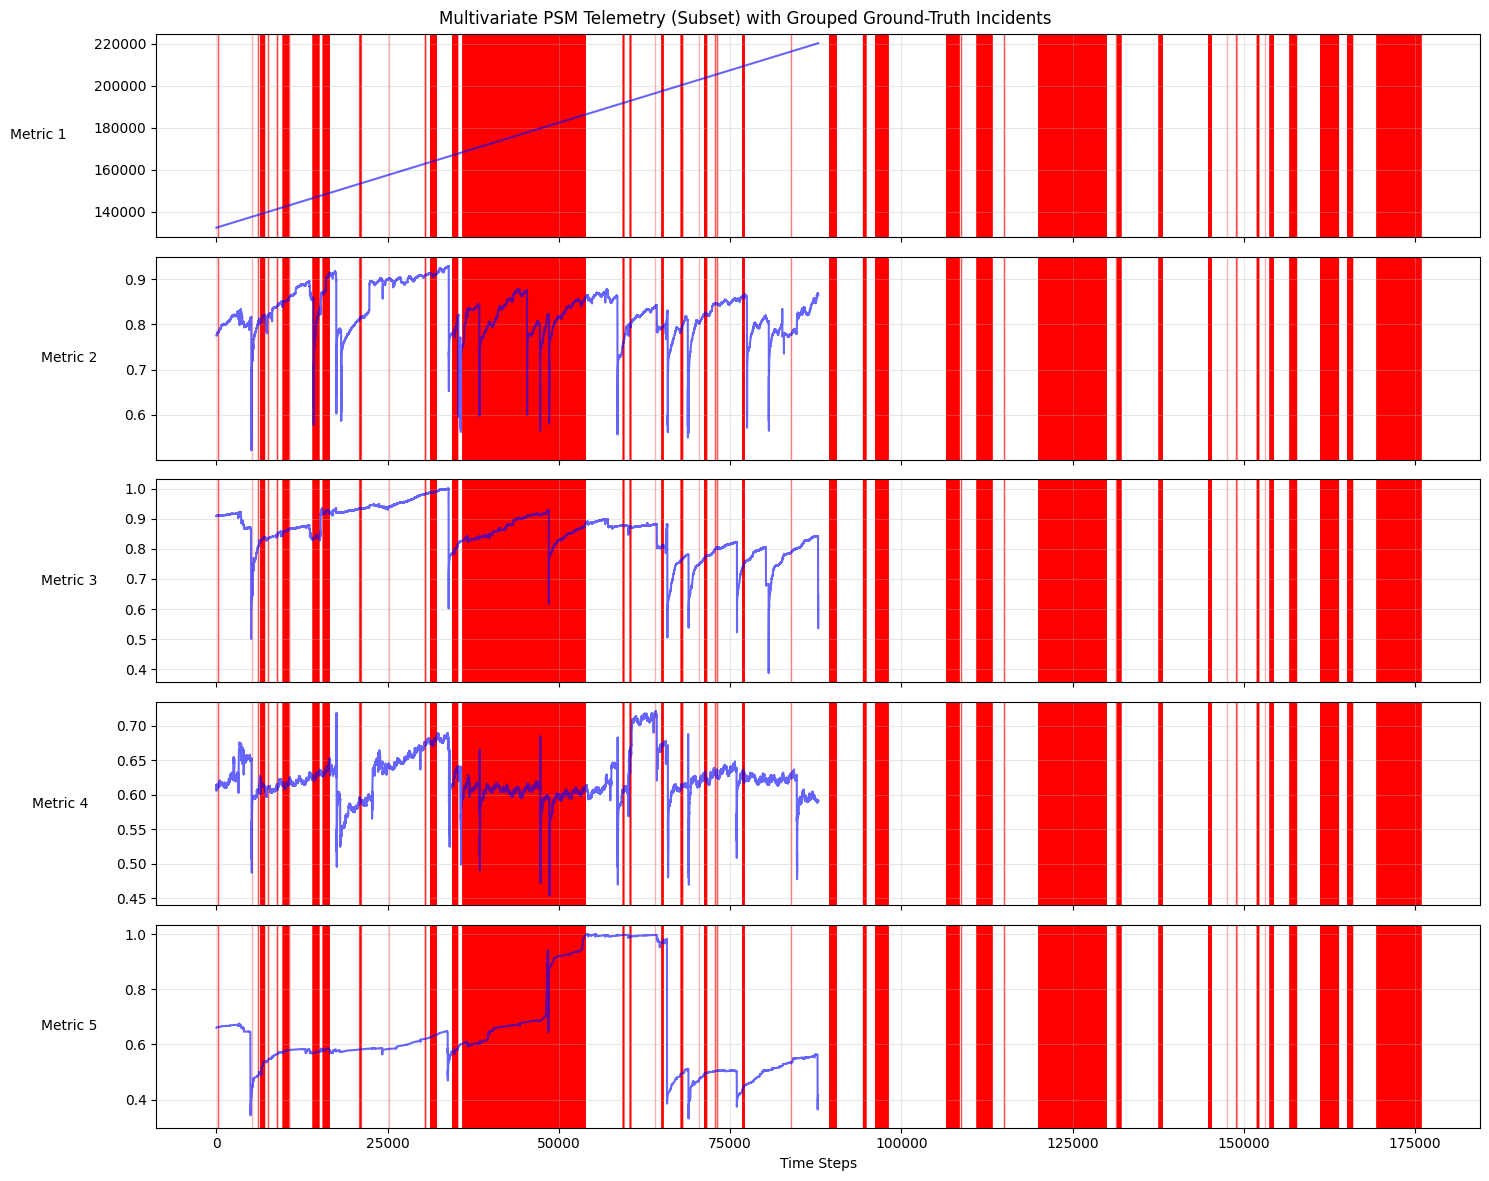

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Adding the root directory to the path to import the src modules
sys.path.append(os.path.abspath('..'))

from src.preprocessing import load_psm_data, prepare_supervised_data

# Ingesting the data through the modular pipeline
test_path = '../data/test.csv'
label_path = '../data/test_label.csv'
full_data, full_labels = load_psm_data(test_path, label_path)

# Executing the 3-way split and windowing logic
(X_train, y_train), (X_cal, y_cal), (X_eval, y_eval) = prepare_supervised_data(full_data, full_labels)

# Identifying contiguous anomaly blocks for efficient rendering
# This prevents alpha-stacking and minimizes the number of objects Matplotlib has to draw
anomaly_indices = np.where(full_labels == 1)[0]
anomaly_blocks = []

if len(anomaly_indices) > 0:
    start_idx = anomaly_indices[0]
    for i in range(1, len(anomaly_indices)):
        if anomaly_indices[i] != anomaly_indices[i-1] + 1:
            anomaly_blocks.append((start_idx, anomaly_indices[i-1]))
            start_idx = anomaly_indices[i]
    anomaly_blocks.append((start_idx, anomaly_indices[-1]))

# Visualizing a subset of the multivariate telemetry with highlighted incidents
dimensions_to_plot = 5
fig, axes = plt.subplots(nrows=dimensions_to_plot, ncols=1, figsize=(15, 12), sharex=True)

for i in range(dimensions_to_plot):
    axes[i].plot(full_data[:, i], color='blue', alpha=0.6)
    axes[i].set_ylabel(f"Metric {i+1}", rotation=0, labelpad=40, ha='center', va='center')
    axes[i].grid(True, alpha=0.3)
    
    # Highlighting each identified incident block in red
    for block_start, block_end in anomaly_blocks:
        axes[i].axvspan(block_start, block_end, color='red', alpha=0.3)

axes[-1].set_xlabel("Time Steps")
plt.suptitle("Multivariate PSM Telemetry (Subset) with Grouped Ground-Truth Incidents")
plt.tight_layout()
plt.show()

## Model Training and Baseline Probability Extraction

With the architectures defined and the training pipelines encapsulated in the source modules, the next phase is to fit both the LSTM and the Histogram Gradient Boosting models to the historical telemetry.

The deep learning approach requires careful handling of the extreme class imbalance inherent in server failures. I am utilizing a weighted random sampling strategy within the PyTorch data loader to oversample the minority anomaly class. This forces the neural network to learn the mathematical precursors of an incident rather than defaulting to a perpetual safe state.

Conversely, the tree-based ensemble handles this imbalance internally via dynamic cost-function weighting during its fit process. 

After training both models, I will extract their raw probability distributions on the calibration and evaluation sets. These uncalibrated scores act as the foundation for the final threshold optimization phase, where they will be mapped to true empirical probabilities.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.models import AlertingLSTM, get_tree_ensemble
from src.trainer import get_balanced_loader, train_lstm, get_lstm_probabilities, train_tree_ensemble, get_tree_probabilities

# Instantiating the dual classifier architectures
input_dimensions = X_train.shape[2]
hidden_units = 64
stacked_layers = 2

lstm_model = AlertingLSTM(
    input_dim=input_dimensions, 
    hidden_dim=hidden_units, 
    num_layers=stacked_layers
)

tree_model = get_tree_ensemble()

# Configuring the balanced data loader specifically for the neural network
train_loader = get_balanced_loader(X_train, y_train, batch_size=64)

# Executing the training loop for the Long Short-Term Memory network
print("Initiating LSTM training...")
lstm_model = train_lstm(lstm_model, train_loader, epochs=10, learning_rate=0.001)

# Fitting the Histogram Gradient Boosting ensemble on the flattened tabular arrays
print("\nInitiating Tree Ensemble training...")
tree_model = train_tree_ensemble(tree_model, X_train, y_train)

# Extracting raw probability scores across the isolated timeline splits
# These scores represent uncalibrated algorithmic confidence and must be mapped to real-world likelihoods next
lstm_cal_probs = get_lstm_probabilities(lstm_model, X_cal)
lstm_eval_probs = get_lstm_probabilities(lstm_model, X_eval)

tree_cal_probs = get_tree_probabilities(tree_model, X_cal)
tree_eval_probs = get_tree_probabilities(tree_model, X_eval)

print("\nTraining complete. Raw probability distributions extracted for calibration.")

Initiating LSTM training...
Epoch 1/10 | Loss: 0.3667
Epoch 2/10 | Loss: 0.2495
Epoch 3/10 | Loss: 0.2148
Epoch 4/10 | Loss: 0.1954
Epoch 5/10 | Loss: 0.1927
